## World Cup 1930 - 2014 Research

This is a World Cup Research by star8d.
My first **Data Analysis project**.

In this notebook, we explore **how** "home stadium" **advantage** impacts match result;

So, I hope you will enjoy my research

In [1]:
import pandas as pd
import numpy as np

We gonna work with **.xlsx** file where all the info about every WC match from 1930 to 2014 stored
Let's read it first

In [2]:
df = pd.read_excel('WorldCupMatches.xlsx')
df = df.drop_duplicates()
df.head()

,Year,Datetime,Stage,Stadium,City,Home Team Name,Home Team Goals,Away Team Goals,Away Team Name,Win conditions,Attendance,Half-time Home Goals,Half-time Away Goals,Referee,Assistant 1,Assistant 2,RoundID,MatchID,Home Team Initials,Away Team Initials
0,1930,13 Jul 1930 - 15:00,Group 1,Pocitos,Montevideo,France,4,1,Mexico,,4444.0,3,0,LOMBARDI Domingo (URU),CRISTOPHE Henry (BEL),REGO Gilberto (BRA),201,1096,FRA,MEX
1,1930,13 Jul 1930 - 15:00,Group 4,Parque Central,Montevideo,USA,3,0,Belgium,,18346.0,2,0,MACIAS Jose (ARG),MATEUCCI Francisco (URU),WARNKEN Alberto (CHI),201,1090,USA,BEL
2,1930,14 Jul 1930 - 12:45,Group 2,Parque Central,Montevideo,Yugoslavia,2,1,Brazil,,24059.0,2,0,TEJADA Anibal (URU),VALLARINO Ricardo (URU),BALWAY Thomas (FRA),201,1093,YUG,BRA
3,1930,14 Jul 1930 - 14:50,Group 3,Pocitos,Montevideo,Romania,3,1,Peru,,2549.0,1,0,WARNKEN Alberto (CHI),LANGENUS Jean (BEL),MATEUCCI Francisco (URU),201,1098,ROU,PER
4,1930,15 Jul 1930 - 16:00,Group 1,Parque Central,Montevideo,Argentina,1,0,France,,23409.0,0,0,REGO Gilberto (BRA),SAUCEDO Ulises (BOL),RADULESCU Constantin (ROU),201,1085,ARG,FRA


As there is no exact info about Home Country of tournament let's create a dict

In [3]:
hosts = {
    1930: 'Uruguay',
    1934: 'Italy',
    1938: 'France',
    1950: 'Brazil',
    1954: 'Switzerland',
    1958: 'Sweden',
    1962: 'Chile',
    1966: 'England',
    1970: 'Mexico',
    1974: 'Germany', # 'Germany FR' actually
    1978: 'Argentina',
    1982: 'Spain',
    1986: 'Mexico',
    1990: 'Italy',
    1994: 'USA',
    1998: 'France',
    2002: ['Korea Republic', 'Japan'],
    2006: 'Germany',
    2010: 'South Africa',
    2014: 'Brazil'
}

Lets rename all the 'Germany FR' rows just to 'Germany'.

In [4]:
df['Home Team Name'] = df['Home Team Name'].replace('Germany FR', 'Germany')
df['Away Team Name'] = df['Away Team Name'].replace('Germany FR', 'Germany')

Now, lets create a new column to DataFrame to see if **Home Team** is a "**Real Home Team**"
(means that Home Team has played match in it's own country)

In [5]:
def is_real_home_team(row):
    host = hosts.get(row['Year'])
    if isinstance(host, list):
        return row['Home Team Name'] in host
    return row['Home Team Name'] == host

In [6]:
df['Is Real Home Team'] = df.apply(is_real_home_team, axis=1)

Let's see at result

In [7]:
df['Is Real Home Team'].head(15)

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8      True
9     False
10    False
11    False
12    False
13     True
14    False
Name: Is Real Home Team, dtype: bool

Lets look at row №8 to check if the year is 1930 and Home Team is a Uruguay

In [8]:
df.iloc[8]

Year                                     1930
Datetime                 18 Jul 1930 - 14:30 
Stage                                 Group 3
Stadium                    Estadio Centenario
City                              Montevideo 
Home Team Name                        Uruguay
Home Team Goals                             1
Away Team Goals                             0
Away Team Name                           Peru
Win conditions                               
Attendance                            57735.0
Half-time Home Goals                        0
Half-time Away Goals                        0
Referee                   LANGENUS Jean (BEL)
Assistant 1               BALWAY Thomas (FRA)
Assistant 2             CRISTOPHE Henry (BEL)
RoundID                                   201
MatchID                                  1099
Home Team Initials                        URU
Away Team Initials                        PER
Is Real Home Team                        True
Name: 8, dtype: object

So, it works. Now let's calculate amount of matches with "Real Home Team's" and how much of they was won or played in draw.
\+ total match amount

In [9]:
real_home_team_matches = df['Is Real Home Team'].sum()

In [10]:
win_condition = (df['Is Real Home Team']) & (df['Home Team Goals'] > df['Away Team Goals'])
draw_condition = (df['Is Real Home Team']) & (df['Home Team Goals'] == df['Away Team Goals'])
winning_home_team_matches = win_condition.sum()
draw_home_team_matches = draw_condition.sum()

In [11]:
total_match_amount = len(df)

Now lets calculate....
### Percentage of "Real Home Matches"

In [12]:
f"{real_home_team_matches / total_match_amount:.5f}"

'0.10048'

### Percentage of "Winning Real Home Matches"

In [13]:
f"{winning_home_team_matches / real_home_team_matches:.5f}"

'0.71429'

### Percentage of "Draw Real Home Matches"

In [14]:
f"{draw_home_team_matches / real_home_team_matches:.5f}"

'0.20238'

So, ~ 72% of "Real Team Matches" were won by the Home Team and ~ 20% ended in a draw. That means that playing a football match at home really affects the result for the Home Team in a good way (71% win rate and only 100 - 72 - 20 = 8% loss rate). Let's visualise that data with a Bar Chart.

In [15]:
import matplotlib.pyplot as plt

In [16]:
win_rate = float(winning_home_team_matches / real_home_team_matches) * 100
draw_rate = float(draw_home_team_matches / real_home_team_matches) * 100
lose_rate = 100 - win_rate - draw_rate

In [17]:
outcomes = ['Wins', 'Draws', 'Losses']
rates = [win_rate, draw_rate, lose_rate]
colors = ['#2ecc71', '#f39c12', '#e74c3c']

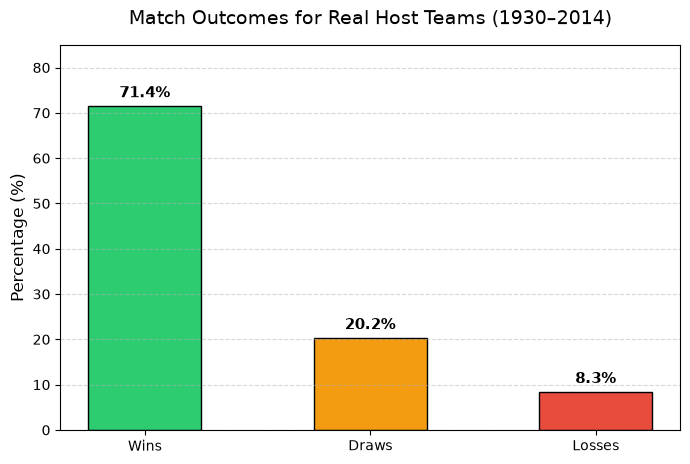

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(outcomes, rates, color=colors, width=0.5, edgecolor='black')
ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=11, fontweight='bold')

ax.set_title('Match Outcomes for Real Host Teams (1930–2014)', fontsize=14, pad=15)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_ylim(0, 85)
ax.grid(axis='y', linestyle='--', alpha=0.5)

Okay, but what if "Real Home Team" wins so often, only because strong football nations host the WC more often?...<br>
Lets CHECK!<br>
My idea is to compare winrate of all Real Home Matches and winrate of Away Matches for every host country for every year. 
<br><br>
DELTA = home_wr - away_wr is our parameter, that shows is there more home wins (DELTA > 0) or away wins (DELTA < 0)

In [19]:
unique_hosts = [
    ('Uruguay', [1930]),
    ('Italy', [1934, 1990]),
    ('France', [1938, 1998]),
    ('Brazil', [1950, 2014]),
    ('Switzerland', [1954]),
    ('Sweden', [1958]),
    ('Chile', [1962]),
    ('England', [1966]),
    ('Mexico', [1970, 1986]),
    ('Germany', [1974, 2006]),
    ('Argentina', [1978]),
    ('Spain', [1982]),
    ('USA', [1994]),
    ('Korea Republic', [2002]),
    ('Japan', [2002]),
    ('South Africa', [2010]),
]

In [20]:
delta_winrates = []

for country, years in unique_hosts:
    is_team = (df['Home Team Name'] == country) | (df['Away Team Name'] == country)
    is_home_year = df['Year'].isin(years)
    
    played_home_cond = is_team & is_home_year
    played_away_cond = is_team & (~is_home_year)
    
    played_home = played_home_cond.sum()
    played_away = played_away_cond.sum()
    
    if played_home == 0 or played_away == 0:
        continue

    win_cond = (
        ((df['Home Team Name'] == country) & (df['Home Team Goals'] > df['Away Team Goals'])) |
        ((df['Away Team Name'] == country) & (df['Away Team Goals'] > df['Home Team Goals']))
    )
    
    won_home = (played_home_cond & win_cond).sum()
    won_away = (played_away_cond & win_cond).sum()
    
    home_winrate = won_home / played_home
    away_winrate = won_away / played_away
    delta = home_winrate - away_winrate
    
    delta_winrates.append({
        'country': country,
        'home_winrate': round(home_winrate, 3),
        'away_winrate': round(away_winrate, 3),
        'delta': round(delta, 3)
    })

In [21]:
len(unique_hosts) == len(delta_winrates)

True

Lets look at mean of DELTA in 'delta_winrates'

In [22]:
res_df = pd.DataFrame(delta_winrates)
mean_delta = res_df['delta'].mean()
mean_delta

np.float64(0.2436875)

And visualise....

In [23]:
res_df[['country', 'home_winrate', 'away_winrate', 'delta']]

,country,home_winrate,away_winrate,delta
0,Uruguay,1.000,0.340,0.660
1,Italy,0.833,0.493,0.340
2,France,0.778,0.420,0.358
3,Brazil,0.538,0.692,-0.154
4,Switzerland,0.500,0.310,0.190
5,Sweden,0.667,0.300,0.367
6,Chile,0.667,0.259,0.407
7,England,0.833,0.375,0.458
8,Mexico,0.556,0.205,0.351
9,Germany,0.786,0.598,0.188


In [24]:
outcomes = res_df['country'].to_list()
rates = res_df['delta'].to_list()

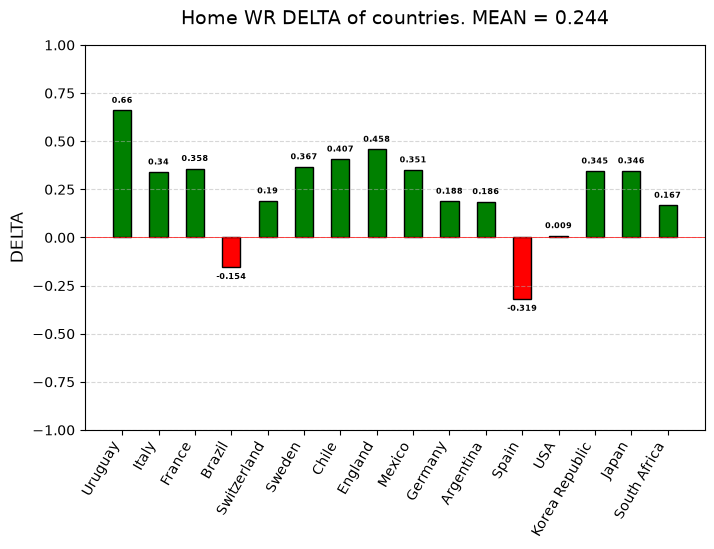

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['green' if r > 0 else 'red' for r in rates]
bars = ax.bar(outcomes, rates, width=0.5, color=colors, edgecolor='black')
ax.bar_label(bars, padding=4, fontsize=6, fontweight='bold')

ax.set_title(f'Home WR DELTA of countries. MEAN = {mean_delta:.3f}', fontsize=14, pad=15)
ax.set_ylabel('DELTA', fontsize=12)
ax.set_ylim(-1, 1)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.axhline(y=0, color='red', linestyle='-', linewidth=0.5)
plt.xticks(rotation=60, ha='right')
plt.show()

We saw that the mean of DELTA is **+0.244** (14 out of 16 hosts performed better at home).  
However, our sample size is small ($n = 16$). Could this difference just be random luck?

#### Hypotheses:
* **$H_0$ (Null Hypothesis):** Home field factor has no effect. The true median difference is zero ($DELTA = 0$).
* **$H_1$ (Alternative Hypothesis):** Playing at home provides a real advantage. The median difference is greater than zero ($DELTA > 0$).

Because our sample size is small and not strictly normally distributed (outliers like Spain and Uruguay), we use the non-parametric **Wilcoxon Signed-Rank Test** for paired samples.

Significance level: $ALPHA = 0.05$.

In [26]:
from scipy import stats

home_rates = res_df['home_winrate']
away_rates = res_df['away_winrate']

stat, p_value = stats.wilcoxon(home_rates, away_rates, alternative='greater')

In [27]:
{f'STAT BY TEST: {float(stat)}, P-VALUE: {float(p_value):.3f}'}

{'STAT BY TEST: 127.0, P-VALUE: 0.001'}

So 0.001 < 0.05, and we can say, that MEAN HOME BOOST (~24%) is ACTUALLY real.

In [28]:
!jupyter nbconvert --to html "World Cup Research.ipynb"

[NbConvertApp] Converting notebook World Cup Research.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 437201 bytes to World Cup Research.html
